# NIPS4B Bird Species Detection

Detect 87 French bird species in soundscape recordings from the NIPS4B 2013 challenge using BEATs and EfficientNet-B0 embeddings with per-species binary probes.

**Workflow:** download → explore → embed → UMAP → training-free metrics (NMI, ARI, R-AUC) → per-species binary probes (linear + sl-BEATs attention) → static + interactive figures → save artifacts.

In [1]:
import warnings

warnings.filterwarnings("ignore")

import pathlib
import sys


def find_repo_root(start: pathlib.Path) -> pathlib.Path:
    for p in [start, *start.parents]:
        if (p / "pyproject.toml").exists():
            return p
    raise FileNotFoundError("Could not locate repo root (pyproject.toml not found).")


REPO_ROOT = find_repo_root(pathlib.Path().resolve())
sys.path.insert(0, str(REPO_ROOT))

import json
import tarfile
import urllib.request

import librosa
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.express as px
import soundfile as sf
import torch
from avex import load_model
from IPython.display import display
from tqdm.auto import tqdm

from utils.probing import compute_training_free_metrics
from utils.visualization import (
    per_species_probe_heatmap_static,
    plot_umap,
    plot_umap_static,
)

EXAMPLE_DIR = REPO_ROOT / "examples" / "04_nips4b_birds"
DATA_DIR = EXAMPLE_DIR / "data"
AUDIO_DIR = DATA_DIR / "audio"
EMBED_DIR = DATA_DIR / "embeddings"
EMBED_DIR.mkdir(parents=True, exist_ok=True)

TARGET_SR = 16_000
DEVICE = "cpu"
BEATS_MODEL = "esp_aves2_sl_beats_all"
EFFNET_MODEL = "esp_aves2_effnetb0_all"
RANDOM_STATE = 42
TEST_SIZE = 0.2
MAX_ITER = 500
print("Setup complete.")

2026-04-20 16:27:57.107314: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


2026-04-20 16:27:59.940338: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


Setup complete.


## 1. Download Dataset

In [2]:
TRAIN_WAV_URL = "https://sabiod.univ-tln.fr/nips4b/media/birds/NIPS4B_BIRD_CHALLENGE_TRAIN_TEST_WAV.tar.gz"
TRAIN_LABELS_URL = "https://sabiod.univ-tln.fr/nips4b/media/birds/NIPS4B_BIRD_CHALLENGE_TRAIN_LABELS.tar"
AUDIO_ARCHIVE = DATA_DIR / "NIPS4B_BIRD_CHALLENGE_TRAIN_TEST_WAV.tar.gz"
LABELS_ARCHIVE = DATA_DIR / "NIPS4B_BIRD_CHALLENGE_TRAIN_LABELS.tar"
EXTRACT_SENTINEL = AUDIO_DIR / ".extracted"
LABELS_DIR = DATA_DIR / "labels"


def download_if_missing(url, dest):
    if dest.exists() and dest.stat().st_size > 1024:
        print(f"  {dest.name} present — skipping.")
        return
    print(f"  Downloading {dest.name} ...")
    urllib.request.urlretrieve(url, dest)


AUDIO_DIR.mkdir(parents=True, exist_ok=True)
LABELS_DIR.mkdir(parents=True, exist_ok=True)
download_if_missing(TRAIN_WAV_URL, AUDIO_ARCHIVE)
download_if_missing(TRAIN_LABELS_URL, LABELS_ARCHIVE)

if not EXTRACT_SENTINEL.exists():
    print("Extracting audio ...")
    with tarfile.open(AUDIO_ARCHIVE, "r:gz") as tf:
        tf.extractall(AUDIO_DIR)
    with tarfile.open(LABELS_ARCHIVE, "r:") as tf:
        tf.extractall(LABELS_DIR)
    EXTRACT_SENTINEL.touch()
    print("Done.")
else:
    print("Audio already extracted.")
print(f"WAV files: {len(list(AUDIO_DIR.rglob('*.wav')))}")

  NIPS4B_BIRD_CHALLENGE_TRAIN_TEST_WAV.tar.gz present — skipping.
  NIPS4B_BIRD_CHALLENGE_TRAIN_LABELS.tar present — skipping.
Audio already extracted.
WAV files: 1687


## 2. Data Exploration

In [3]:
META_PATH = DATA_DIR / "metadata.csv"
df = pd.read_csv(META_PATH)
df["species"] = df["species"].apply(lambda s: s.split(";") if isinstance(s, str) and s else [])
df["n_species"] = df["species"].apply(len)
df["dominant_species"] = df["species"].apply(lambda xs: xs[0] if xs else "")

base = REPO_ROOT
df["path"] = df["path"].apply(lambda p: str(base / p) if not p.startswith("/") else p)
df = df[(df["n_species"] > 0) & df["path"].apply(lambda p: pathlib.Path(p).exists())].reset_index(drop=True)

all_species = sorted({sp for lst in df["species"] for sp in lst})
print(f"Working set: {len(df)} recordings, {len(all_species)} unique species")

Working set: 542 recordings, 51 unique species


In [4]:
top_species = df["dominant_species"].value_counts().head(20)
fig = px.bar(
    top_species, title="Top 20 dominant species in recordings", labels={"value": "Recordings", "index": "Species"}
)
fig.update_layout(xaxis_tickangle=-45, showlegend=False)
fig.show()

## 3. Embedding Extraction

In [5]:
CLIP_DURATION_S = 10.0


def load_audio(path: str, target_sr: int = TARGET_SR) -> torch.Tensor:
    """Load up to CLIP_DURATION_S of a WAV, resample to target_sr."""
    info = sf.info(path)
    n_orig = int(min(CLIP_DURATION_S, info.duration) * info.samplerate)
    wav, sr = sf.read(path, frames=n_orig, dtype="float32", always_2d=True)
    wav = wav.mean(axis=1)
    if sr != target_sr:
        wav = librosa.resample(wav, orig_sr=sr, target_sr=target_sr)
    return torch.from_numpy(wav).unsqueeze(0)


print(f"Sample shape: {load_audio(df['path'].iloc[0]).shape}")

Sample shape: torch.Size([1, 80063])


In [6]:
BEATS_CACHE = EMBED_DIR / "beats_embeddings.npy"

if BEATS_CACHE.exists() and np.load(BEATS_CACHE).shape[0] == len(df):
    beats_embs = np.load(BEATS_CACHE)
    print(f"Loaded cached BEATs last-layer embeddings: {beats_embs.shape}")
else:
    print(f"Loading model: {BEATS_MODEL}")
    model = load_model(BEATS_MODEL, return_features_only=True, device=DEVICE)
    model.eval()
    embeddings = []
    with torch.no_grad():
        for path in tqdm(df["path"].tolist(), desc="BEATs last-layer"):
            wav = load_audio(path)
            feats = model(wav)  # (1, T, 768)
            embeddings.append(feats.mean(dim=1).squeeze(0).cpu().numpy())
    beats_embs = np.stack(embeddings)
    np.save(BEATS_CACHE, beats_embs)
    print(f"Saved BEATs last-layer embeddings: {beats_embs.shape}")
    del model

Loaded cached BEATs last-layer embeddings: (542, 768)


In [7]:
BEATS_ALL_CACHE = EMBED_DIR / "beats_all_layers_embeddings.npy"

if BEATS_ALL_CACHE.exists() and np.load(BEATS_ALL_CACHE).shape[0] == len(df):
    beats_all_embs = np.load(BEATS_ALL_CACHE)
    print(f"Loaded cached BEATs all-layers embeddings: {beats_all_embs.shape}")
else:
    print(f"Loading model for all-layers extraction: {BEATS_MODEL}")
    model = load_model(BEATS_MODEL, return_features_only=True, device=DEVICE)
    model.eval()

    # Register forward hooks on every transformer encoder layer
    try:
        encoder_layers = model.model.encoder.layers
    except AttributeError:
        encoder_layers = model.backbone.encoder.layers
    n_layers = len(encoder_layers)
    layer_store: dict = {}
    hooks = []
    for i, layer in enumerate(encoder_layers):

        def _make_hook(idx):
            def _hook(module, inp, out):
                layer_store[idx] = out[0] if isinstance(out, tuple) else out

            return _hook

        hooks.append(layer.register_forward_hook(_make_hook(i)))
    print(f"  Registered hooks on {n_layers} transformer layers.")

    all_embs = []
    with torch.no_grad():
        for path in tqdm(df["path"], desc="BEATs all-layers"):
            layer_store.clear()
            wav = load_audio(path)
            _ = model(wav)
            # Mean-pool each layer then average across layers → (D,)
            # Handles both time-first (T, B, D) and batch-first (B, T, D) outputs
            per_layer = [
                layer_store[i].view(-1, layer_store[i].shape[-1]).mean(dim=0).cpu().numpy() for i in range(n_layers)
            ]
            all_embs.append(np.mean(per_layer, axis=0))

    for h in hooks:
        h.remove()

    beats_all_embs = np.stack(all_embs)
    np.save(BEATS_ALL_CACHE, beats_all_embs)
    print(f"Saved BEATs all-layers embeddings: {beats_all_embs.shape}")
    del model

Loaded cached BEATs all-layers embeddings: (542, 768)


In [8]:
EFFNET_CACHE = EMBED_DIR / "effnet_embeddings.npy"

if EFFNET_CACHE.exists() and np.load(EFFNET_CACHE).shape[0] == len(df):
    effnet_embs = np.load(EFFNET_CACHE)
    print(f"Loaded cached EfficientNet embeddings: {effnet_embs.shape}")
else:
    print(f"Loading model: {EFFNET_MODEL}")
    model = load_model(EFFNET_MODEL, return_features_only=True, device=DEVICE)
    model.eval()
    embeddings = []
    with torch.no_grad():
        for path in tqdm(df["path"].tolist(), desc="EfficientNet"):
            wav = load_audio(path)
            feats = model(wav)  # (1, C, H, W)
            embeddings.append(feats.mean(dim=(2, 3)).squeeze(0).cpu().numpy())
    effnet_embs = np.stack(embeddings)
    np.save(EFFNET_CACHE, effnet_embs)
    print(f"Saved EfficientNet embeddings: {effnet_embs.shape}")
    del model

Loaded cached EfficientNet embeddings: (542, 1280)


## 4. UMAP Visualisation

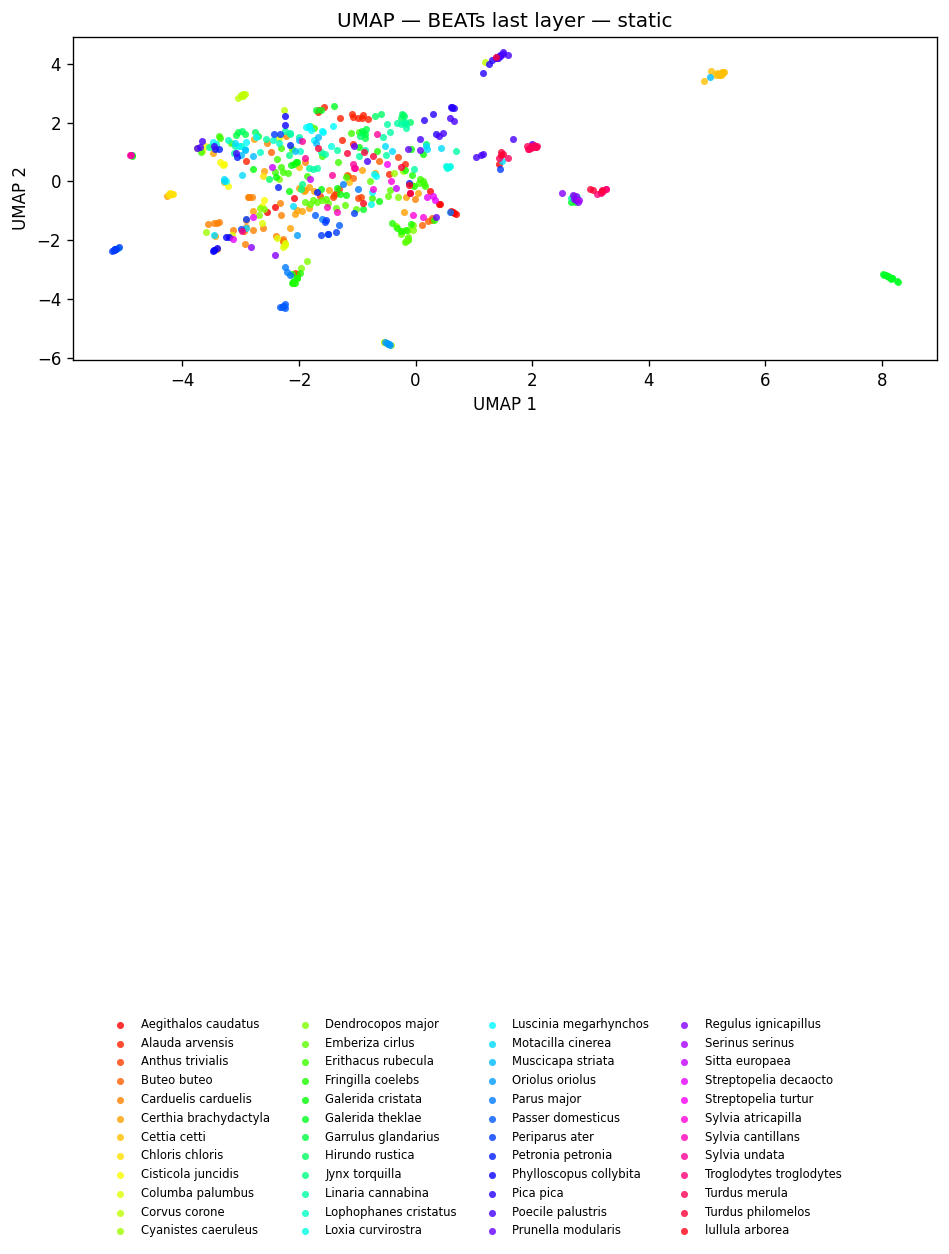

In [9]:
hover = [
    f"{row.get('filename', row['path'].split('/')[-1])}<br>Species: {', '.join(row['species'])}"
    for _, row in df.iterrows()
]
dom_labels = df["dominant_species"].tolist()

fig_beats = plot_umap(
    beats_embs,
    labels=dom_labels,
    title=f"UMAP — {BEATS_MODEL} (last layer)<br><sup>colour = dominant species</sup>",
    hover_text=hover,
)
fig_beats.show()
fig_umap_beats_static = plot_umap_static(
    beats_embs, labels=dom_labels, title=f"UMAP — {BEATS_MODEL} (last layer) — static"
)
display(fig_umap_beats_static)

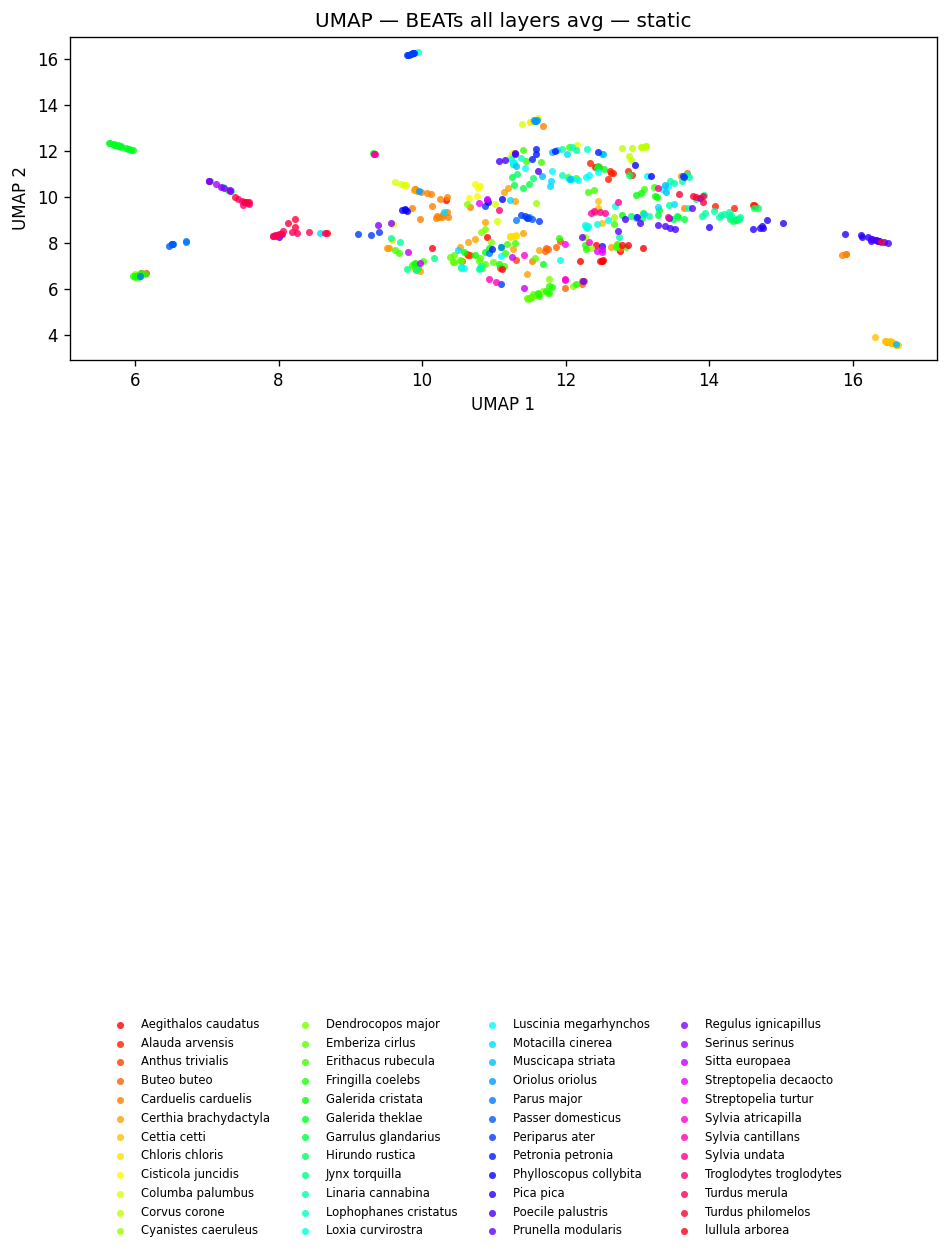

In [10]:
fig_beats_all = plot_umap(
    beats_all_embs, labels=dom_labels, title=f"UMAP — {BEATS_MODEL} (all layers avg)", hover_text=hover
)
fig_beats_all.show()
fig_umap_beats_all_static = plot_umap_static(
    beats_all_embs, labels=dom_labels, title=f"UMAP — {BEATS_MODEL} (all layers avg) — static"
)
display(fig_umap_beats_all_static)

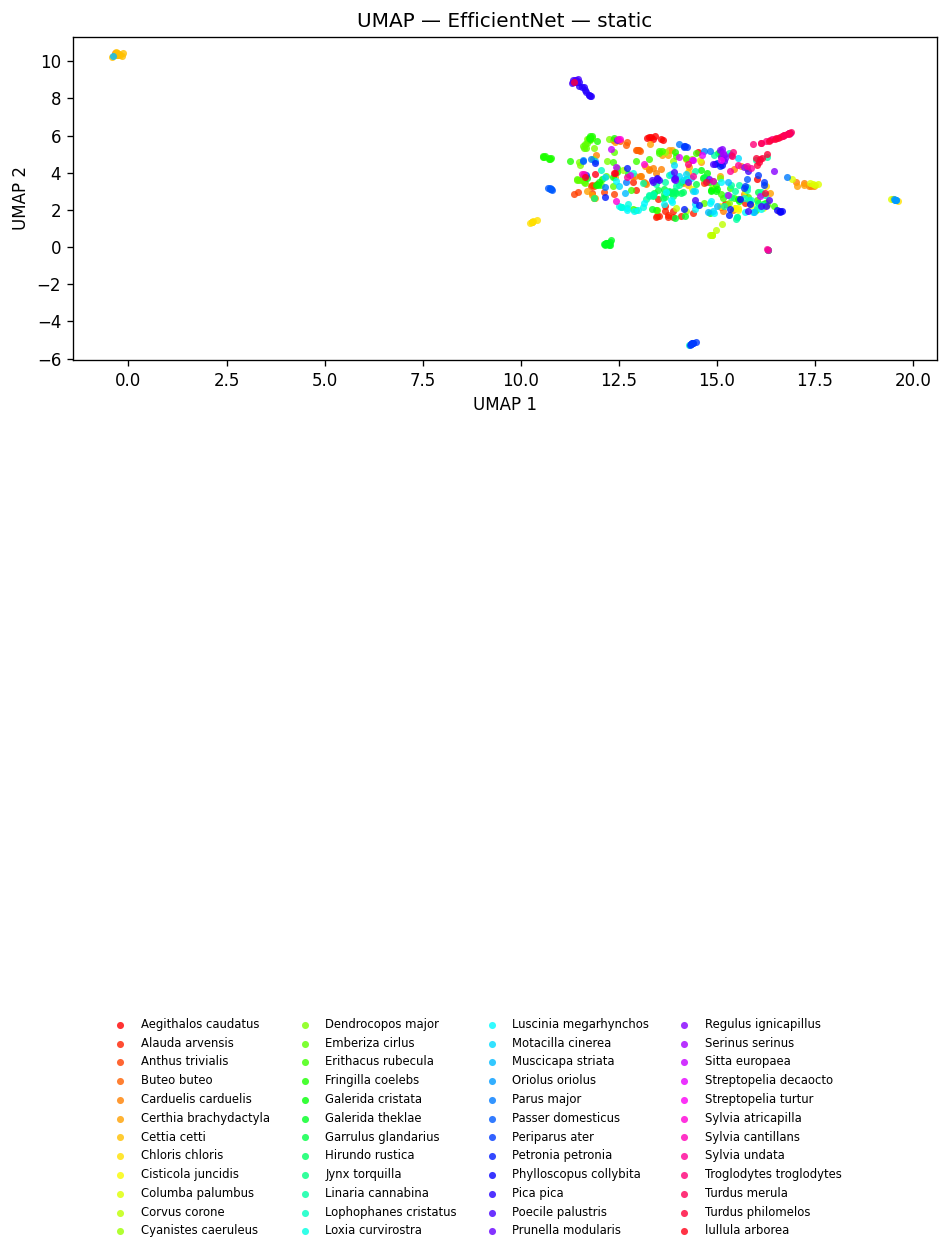

In [11]:
fig_effnet = plot_umap(effnet_embs, labels=dom_labels, title=f"UMAP — {EFFNET_MODEL}", hover_text=hover)
fig_effnet.show()
fig_umap_effnet_static = plot_umap_static(effnet_embs, labels=dom_labels, title=f"UMAP — {EFFNET_MODEL} — static")
display(fig_umap_effnet_static)

## 5. Training-Free Metrics

In [12]:
print("Computing training-free metrics (NMI, ARI, R-AUC) ...")
print("These evaluate embedding quality without fitting any classifier.\n")

_labels_for_metrics = dom_labels

_metric_models = [
    (f"{BEATS_MODEL} (last layer)", beats_embs),
    (f"{BEATS_MODEL} (all layers avg)", beats_all_embs),
    (EFFNET_MODEL, effnet_embs),
]

_metric_rows = []
for _name, _embs in _metric_models:
    _m = compute_training_free_metrics(_embs, _labels_for_metrics)
    _metric_rows.append(
        {"Model": _name, "NMI": round(_m["nmi"], 3), "ARI": round(_m["ari"], 3), "R-AUC": round(_m["r_auc"], 3)}
    )
    print(f"  {_name}: NMI={_m['nmi']:.3f}  ARI={_m['ari']:.3f}  R-AUC={_m['r_auc']:.3f}")

_metrics_df = pd.DataFrame(_metric_rows).set_index("Model")
display(_metrics_df)

Computing training-free metrics (NMI, ARI, R-AUC) ...
These evaluate embedding quality without fitting any classifier.



  esp_aves2_sl_beats_all (last layer): NMI=0.590  ARI=0.167  R-AUC=0.302


  esp_aves2_sl_beats_all (all layers avg): NMI=0.614  ARI=0.213  R-AUC=0.294


  esp_aves2_effnetb0_all: NMI=0.577  ARI=0.173  R-AUC=0.297


,NMI,ARI,R-AUC
Model,,,
esp_aves2_sl_beats_all (last layer),0.590,0.167,0.302
esp_aves2_sl_beats_all (all layers avg),0.614,0.213,0.294
esp_aves2_effnetb0_all,0.577,0.173,0.297


## 5b. Recording-Level Train/Test Split

The official NIPS4B dataset includes separate `train/` and `test/` audio folders, but **labels are only provided for the training set**.
So for evaluation inside this notebook, we create an **internal** train/test split **at the recording level** (no clip appears in both splits).

We use a **stratified random split** based on `dominant_species` so train/test have similar class composition.

In [13]:
from sklearn.model_selection import StratifiedShuffleSplit

_strat_labels = df["dominant_species"].astype(str).to_numpy()
_splitter = StratifiedShuffleSplit(
    n_splits=1,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
)

TRAIN_IDX, TEST_IDX = next(_splitter.split(np.zeros(len(df)), _strat_labels))
TRAIN_IDX = np.asarray(TRAIN_IDX, dtype=int)
TEST_IDX = np.asarray(TEST_IDX, dtype=int)

print(f"Train recordings: {len(TRAIN_IDX)}  |  Test recordings: {len(TEST_IDX)}")

# Quick sanity check that the split preserved the dominant-species mix.
_train_top = df.iloc[TRAIN_IDX]["dominant_species"].value_counts(normalize=True).head(5)
_test_top = df.iloc[TEST_IDX]["dominant_species"].value_counts(normalize=True).head(5)
print("\nTop dominant species (train, %):")
print((_train_top * 100).round(1).astype(str) + "%")
print("\nTop dominant species (test, %):")
print((_test_top * 100).round(1).astype(str) + "%")

Train recordings: 434  |  Test recordings: 108
Test recording numbers: [549, 550, 551, 553, 554] ... (total 108)


## 6. Per-Species Binary Probes

In [14]:
MIN_POSITIVE = 5
ATTN_EPOCHS = 10

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import balanced_accuracy_score


def _run_attention_probe_fixed_split(
    embeddings: np.ndarray,
    y: np.ndarray,
    train_idx: np.ndarray,
    test_idx: np.ndarray,
    *,
    num_heads: int,
    num_attn_layers: int,
    epochs: int,
    lr: float,
    batch_size: int,
    device: str,
    random_state: int,
) -> float:
    """AttentionProbe trained on TRAIN_IDX and evaluated on TEST_IDX."""
    from avex.models.probes import AttentionProbe

    x_train = embeddings[train_idx]
    y_train = y[train_idx]
    x_test = embeddings[test_idx]
    y_test = y[test_idx]

    # Upsample minority class in the training set (binary probe).
    rng = np.random.default_rng(random_state)
    cls_u, cnt_u = np.unique(y_train, return_counts=True)
    max_cnt = int(cnt_u.max())
    x_parts, y_parts = [], []
    for cls in cls_u:
        mask = y_train == cls
        xc = x_train[mask]
        yc = y_train[mask]
        if len(xc) < max_cnt:
            sel = rng.integers(0, len(xc), size=max_cnt)
            xc = xc[sel]
            yc = yc[sel]
        x_parts.append(xc)
        y_parts.append(yc)
    x_train = np.vstack(x_parts)
    y_train = np.concatenate(y_parts)

    # Ensure 3D input for AttentionProbe.
    if x_train.ndim == 2:
        x_train_3d = x_train[:, np.newaxis, :]
        x_test_3d = x_test[:, np.newaxis, :]
    else:
        x_train_3d = x_train
        x_test_3d = x_test

    feat_dim = int(x_train_3d.shape[-1])
    while feat_dim % num_heads != 0 and num_heads > 1:
        num_heads -= 1

    probe = AttentionProbe(
        base_model=None,
        layers=[],
        num_classes=2,
        device=device,
        feature_mode=True,
        input_dim=feat_dim,
        num_heads=num_heads,
        num_layers=num_attn_layers,
    )

    optimizer = torch.optim.Adam(probe.parameters(), lr=lr)
    criterion = torch.nn.CrossEntropyLoss()

    x_tr = torch.tensor(x_train_3d, dtype=torch.float32).to(device)
    y_tr = torch.tensor(y_train, dtype=torch.long).to(device)
    x_te = torch.tensor(x_test_3d, dtype=torch.float32).to(device)

    for _ in range(epochs):
        probe.train()
        perm = torch.randperm(len(x_tr))
        for i in range(0, len(x_tr), batch_size):
            idx = perm[i : i + batch_size]
            optimizer.zero_grad()
            loss = criterion(probe(x_tr[idx]), y_tr[idx])
            loss.backward()
            optimizer.step()

    probe.eval()
    with torch.no_grad():
        y_pred = probe(x_te).argmax(1).cpu().numpy()

    return float(balanced_accuracy_score(y_test, y_pred))


eligible = [sp for sp in all_species if sum(sp in lst for lst in df["species"]) >= MIN_POSITIVE]
print(
    f"Running binary probes for {len(eligible)}/{len(all_species)} species "
    f"(≥{MIN_POSITIVE} positives) using the recording-level split ..."
)

probe_rows = []
for sp in tqdm(eligible, desc="species probes (recording split)"):
    y = np.array([1 if sp in lst else 0 for lst in df["species"]], dtype=int)
    y_train_sp = y[TRAIN_IDX]
    y_test_sp = y[TEST_IDX]
    n_pos = int(y.sum())
    n_neg = int(len(y) - n_pos)

    # Species not represented in both splits — skip.
    if np.unique(y_train_sp).size < 2 or np.unique(y_test_sp).size < 2:
        continue

    for emb_name, embs in [
        (f"{BEATS_MODEL} (last layer)", beats_embs),
        (f"{BEATS_MODEL} (all layers avg)", beats_all_embs),
        (EFFNET_MODEL, effnet_embs),
    ]:
        clf = LogisticRegression(max_iter=MAX_ITER, random_state=RANDOM_STATE)
        clf.fit(embs[TRAIN_IDX], y_train_sp)
        y_pred_sp = clf.predict(embs[TEST_IDX])
        bal_acc = float(balanced_accuracy_score(y_test_sp, y_pred_sp))
        probe_rows.append(
            {
                "species": sp,
                "model": emb_name,
                "n_pos": n_pos,
                "n_neg": n_neg,
                "balanced_accuracy": round(bal_acc, 4),
            }
        )

        if emb_name != EFFNET_MODEL:
            bal_a = _run_attention_probe_fixed_split(
                embs,
                y,
                TRAIN_IDX,
                TEST_IDX,
                num_heads=8,
                num_attn_layers=2,
                epochs=ATTN_EPOCHS,
                lr=1e-3,
                batch_size=64,
                device=DEVICE,
                random_state=RANDOM_STATE,
            )
            probe_rows.append(
                {
                    "species": sp,
                    "model": f"{emb_name} — attention",
                    "n_pos": n_pos,
                    "n_neg": n_neg,
                    "balanced_accuracy": round(float(bal_a), 4),
                }
            )

probe_df = pd.DataFrame(probe_rows)
display(probe_df.sort_values("balanced_accuracy", ascending=False).head(10))

Running binary probes for 51/51 species (≥5 positives) using the recording-level split ...


species probes (recording split):   0%|          | 0/51 [00:00<?, ?it/s]

,species,model,n_pos,n_neg,balanced_accuracy
13,Anthus trivialis,esp_aves2_sl_beats_all (all layers avg) — atte...,10,532,1.0
14,Anthus trivialis,esp_aves2_effnetb0_all,10,532,1.0
10,Anthus trivialis,esp_aves2_sl_beats_all (last layer),10,532,1.0
11,Anthus trivialis,esp_aves2_sl_beats_all (last layer) — attention,10,532,1.0
51,Corvus corone,esp_aves2_sl_beats_all (last layer) — attention,10,532,1.0
53,Corvus corone,esp_aves2_sl_beats_all (all layers avg) — atte...,10,532,1.0
52,Corvus corone,esp_aves2_sl_beats_all (all layers avg),10,532,1.0
47,Columba palumbus,esp_aves2_sl_beats_all (all layers avg),10,532,1.0
48,Columba palumbus,esp_aves2_sl_beats_all (all layers avg) — atte...,10,532,1.0
49,Columba palumbus,esp_aves2_effnetb0_all,10,532,1.0


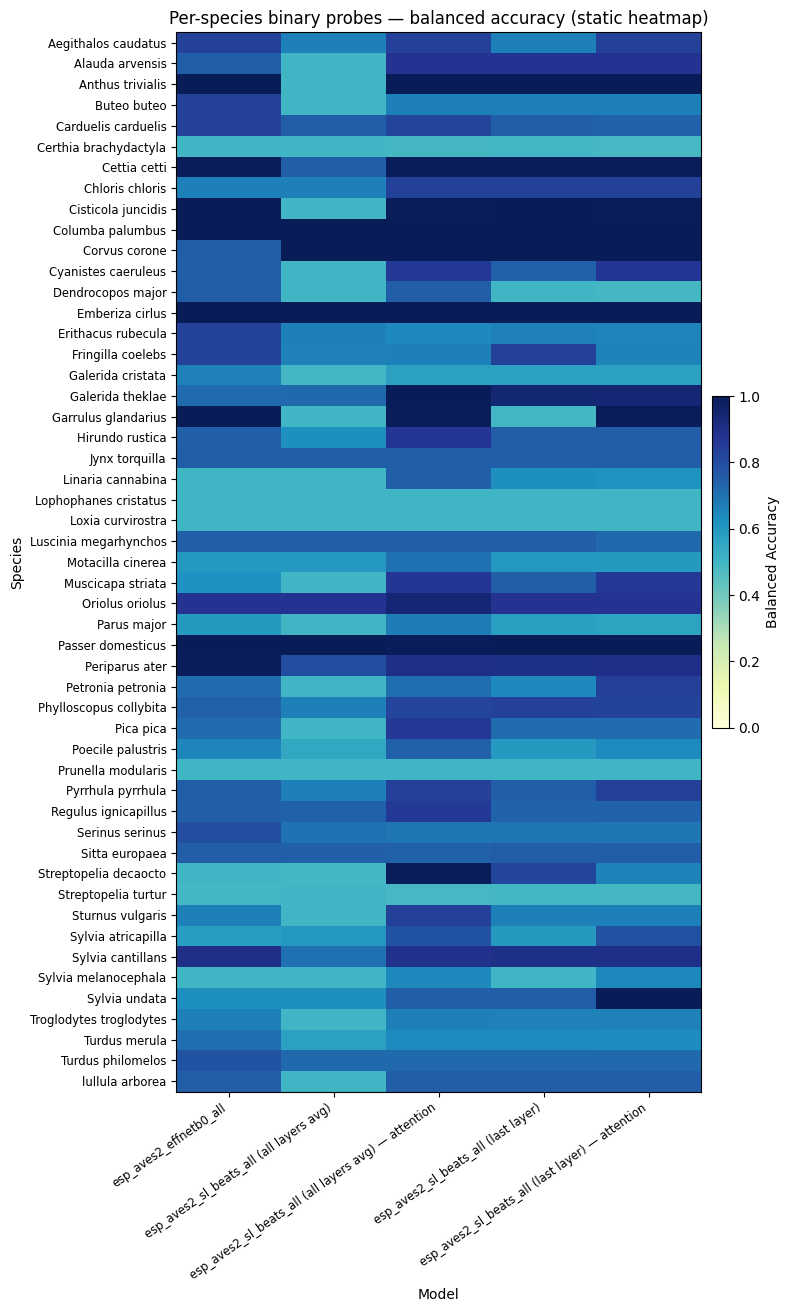

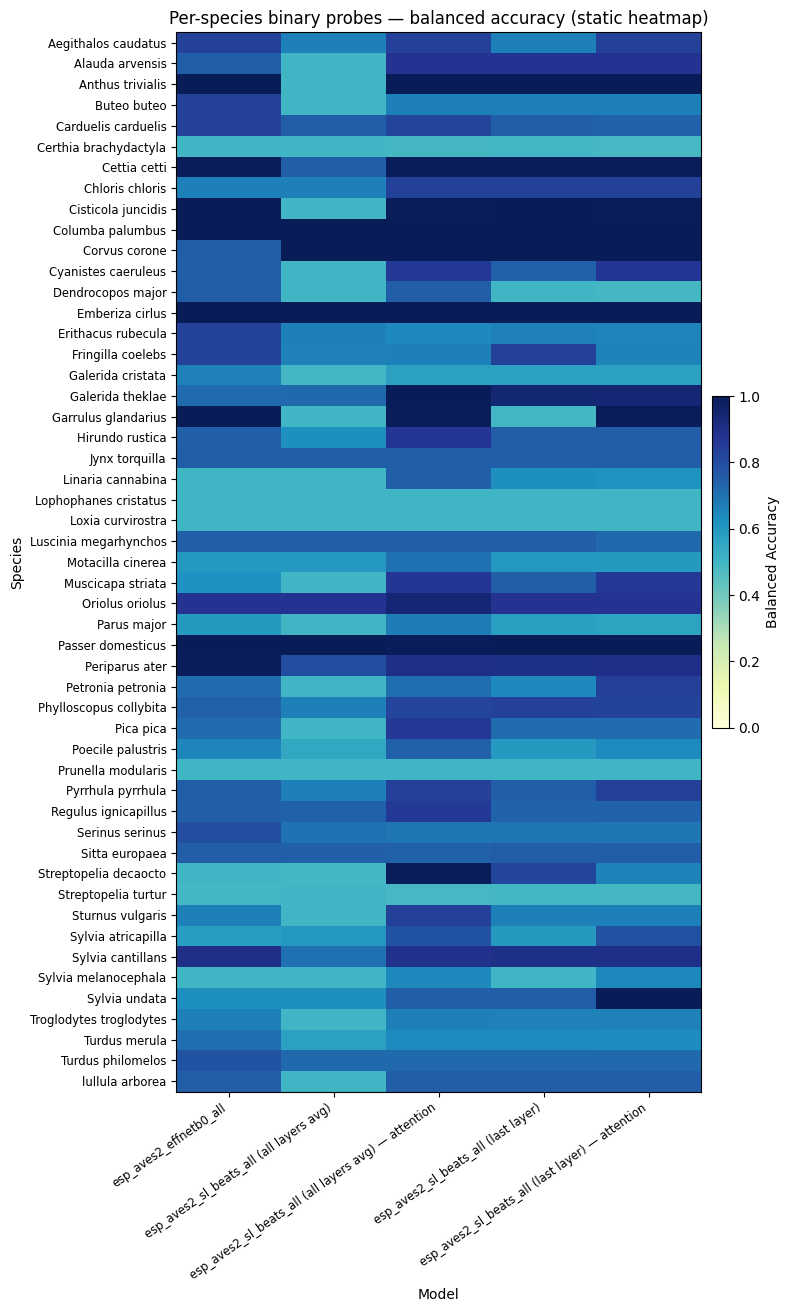

In [15]:
species_order = probe_df.groupby("species")["balanced_accuracy"].mean().sort_values(ascending=True).index.tolist()
fig_probe = px.bar(
    probe_df,
    x="balanced_accuracy",
    y="species",
    color="model",
    barmode="group",
    orientation="h",
    category_orders={"species": species_order},
    title="Per-species binary probe — balanced accuracy (NIPS4B birds)",
    labels={"balanced_accuracy": "Balanced accuracy", "species": ""},
    height=max(600, 30 * len(eligible)),
)
fig_probe.add_vline(x=0.5, line_dash="dot", line_color="grey", annotation_text="chance")
fig_probe.show()

fig_probe_static = per_species_probe_heatmap_static(
    probe_df,
    title="Per-species binary probes — balanced accuracy (static heatmap)",
)
display(fig_probe_static)

## 6b. (Removed) Redundant probe block

The per-species probes above already use the **recording-level train/test split**, so we don’t re-run them a second time.

In [16]:
# Probes already computed above using TRAIN_IDX / TEST_IDX.

_mean_rec = probe_df.groupby("model")["balanced_accuracy"].mean()
print("\nMean balanced accuracy (recording-level split):")
for model, acc in _mean_rec.items():
    print(f"  {model}: {acc:.3f}")


Mean balanced accuracy (recording-level split):
  esp_aves2_effnetb0_all: 0.738
  esp_aves2_sl_beats_all (all layers avg): 0.629
  esp_aves2_sl_beats_all (all layers avg) — attention: 0.786
  esp_aves2_sl_beats_all (last layer): 0.732
  esp_aves2_sl_beats_all (last layer) — attention: 0.758


## 8. Save Artifacts

In [17]:
ARTIFACTS_DIR = EXAMPLE_DIR / "artifacts"
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

fig_beats.write_html(str(ARTIFACTS_DIR / "umap_beats.html"))
fig_beats_all.write_html(str(ARTIFACTS_DIR / "umap_beats_all_layers.html"))
fig_effnet.write_html(str(ARTIFACTS_DIR / "umap_effnet.html"))
fig_probe.write_html(str(ARTIFACTS_DIR / "per_species_probe.html"))

fig_umap_beats_static.savefig(str(ARTIFACTS_DIR / "umap_beats_static.png"), dpi=150, bbox_inches="tight")
fig_umap_beats_all_static.savefig(str(ARTIFACTS_DIR / "umap_beats_all_layers_static.png"), dpi=150, bbox_inches="tight")
fig_umap_effnet_static.savefig(str(ARTIFACTS_DIR / "umap_effnet_static.png"), dpi=150, bbox_inches="tight")
fig_probe_static.savefig(str(ARTIFACTS_DIR / "per_species_probe_static.png"), dpi=150, bbox_inches="tight")
plt.close("all")

_mean_bal_acc = probe_df.groupby("model")["balanced_accuracy"].mean().to_dict()
_metrics_out = {
    "n_recordings": len(df),
    "n_species": len(all_species),
    "training_free": {
        k: compute_training_free_metrics(v, dom_labels)
        for k, v in [("beats_last", beats_embs), ("beats_all_layers", beats_all_embs), ("effnet", effnet_embs)]
    },
    "mean_balanced_accuracy_per_model": {k: round(v, 4) for k, v in _mean_bal_acc.items()},
}
with open(ARTIFACTS_DIR / "nips4b_metrics.json", "w") as _f:
    json.dump(_metrics_out, _f, indent=2)
print(f"Artifacts saved to {ARTIFACTS_DIR}")

Artifacts saved to /home/marius_miron_earthspecies_org/code/avex-examples/examples/04_nips4b_birds/artifacts
